# comprension_eda.ipynb

## Propósito

Análisis Exploratorio de Datos (EDA) profundo del dataset histórico de créditos `Base_de_datos.xlsx`. Este notebook desarrolla los tres niveles de análisis previstos en el Proyecto Integrador:

- **Análisis univariable:** distribución y características de cada variable individualmente.
- **Análisis bivariable:** relación de cada variable predictora con la variable objetivo `Pago_atiempo`.
- **Análisis multivariable:** correlaciones, multicolinealidad y relaciones entre múltiples variables simultáneamente.

El notebook trabaja sobre el dataset **crudo**: las decisiones de imputación, encoding, transformación y eliminación de outliers se postergan al script `ft_engineering.py` (versión V1.1.0).

## Versión

**V1.0.1** - EDA completo.

## 0. Setup

Importaciones, configuración global y carga del dataset.

### 0.1 Importaciones

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística: tests inferenciales y análisis de multicolinealidad
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Utilitarios
import warnings
warnings.filterwarnings('ignore')  # Suprime warnings menores para limpieza de output

# Confirmación de versiones
print(f'pandas:      {pd.__version__}')
print(f'numpy:       {np.__version__}')
print(f'seaborn:     {sns.__version__}')

pandas:      2.3.3
numpy:       2.4.6
seaborn:     0.13.2


### 0.2 Configuración global

Se establecen opciones de visualización para que las salidas sean consistentes y legibles a lo largo del notebook.

In [3]:
# Pandas: que no recorte columnas al mostrar DataFrames anchos
pd.set_option('display.max_columns', None)

# Pandas: mostrar números flotantes con 2 decimales, sin notación científica
pd.set_option('display.float_format', '{:.2f}'.format)

# Pandas: ancho máximo de columna (para que el texto largo no se corte)
pd.set_option('display.max_colwidth', 80)

# Seaborn: tema visual consistente para todos los gráficos
sns.set_theme(style='whitegrid', palette='deep', context='notebook')

# Matplotlib: resolución de figuras (más alto = más nítido)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

# Semilla para reproducibilidad (cualquier muestreo aleatorio será reproducible)
SEMILLA = 42
np.random.seed(SEMILLA)

# Paleta de colores estable para los dos valores del target
# Convención: rojo para riesgo (no paga), verde-azul para cumplimiento (paga)
COLORES_TARGET = {0: '#D9534F', 1: '#5BC0DE'}

print('Configuración global aplicada.')

Configuración global aplicada.


### 0.3 Carga del dataset

Este notebook carga el dataset de forma **independiente** de `Cargar_datos.ipynb`, conforme a la decisión metodológica de mantener cada notebook autocontenido.

In [4]:
# Ruta relativa desde mlops_pipeline/src/ hacia la raíz del repositorio
RUTA_DATASET = '../../Base_de_datos.xlsx'

df = pd.read_excel(RUTA_DATASET)

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dataset cargado: 10,763 filas x 23 columnas


## 1. Exploración inicial

Primera mirada al dataset: estructura, tipos, integridad y composición.

### 1.1 Dimensiones, tipos de datos y vistazo a las filas

In [6]:
print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print(f'\nTipos de datos detectados por pandas:')
df.dtypes.value_counts().to_frame('cantidad_columnas')

Dimensiones: 10,763 filas x 23 columnas
Memoria utilizada: 2.85 MB

Tipos de datos detectados por pandas:


,cantidad_columnas
int64,12
float64,8
object,2
datetime64[ns],1


In [7]:
# Detalle por columna
tipos_detalle = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unicos': df.nunique(dropna=True),
    'n_nulos': df.isnull().sum(),
    'pct_nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
tipos_detalle

,dtype,n_unicos,n_nulos,pct_nulos
tipo_credito,int64,6,0,0.00
fecha_prestamo,datetime64[ns],10758,0,0.00
capital_prestado,float64,7306,0,0.00
plazo_meses,int64,18,0,0.00
edad_cliente,int64,54,0,0.00
tipo_laboral,object,2,0,0.00
salario_cliente,int64,1385,0,0.00
total_otros_prestamos,int64,1538,0,0.00
cuota_pactada,int64,9836,0,0.00
puntaje,float64,248,0,0.00


In [8]:
# Primeras 5 filas
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.00,10,42,Independiente,8000000,2500000,341296,88.77,695.00,10,5,0.00,51258.00,51258.00,0.00,5,0,0,908526.00,Estable,1
1,4,2025-04-22 09:47:35,840000.00,6,60,Empleado,3000000,2000000,124876,95.23,789.00,3,1,0.00,8673.00,8673.00,0.00,0,0,2,939017.00,Creciente,1
2,9,2026-01-08 12:22:40,5974028.40,10,36,Independiente,4036000,829000,529554,47.61,740.00,4,5,0.00,18702.00,18702.00,0.00,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.00,6,48,Empleado,1524547,498000,252420,95.23,837.00,4,4,0.00,15782.00,15782.00,0.00,3,0,0,1536193.00,Creciente,1
4,9,2025-04-26 11:24:26,2781636.00,11,44,Empleado,5000000,4000000,217037,95.23,771.00,4,6,0.00,204804.00,204804.00,0.00,3,0,1,933473.00,Creciente,1


In [9]:
# Últimas 5 filas (útil para verificar consistencia al final del dataset)
df.tail()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
10758,9,2025-01-19 16:18:28,2414886.00,10,29,Independiente,3000000,300000,204819,13.13,747.00,2,2,172.00,1112.00,1112.00,NaN,0,0,1,NaN,NaN,0
10759,4,2025-01-10 16:40:21,2916000.00,24,27,Empleado,2500000,400000,127460,55.97,714.00,5,4,0.00,9771.00,9771.00,0.00,1,0,4,1958333.00,Creciente,0
10760,4,2025-06-19 14:28:47,4249200.00,36,24,Empleado,2000000,500000,140042,47.61,807.00,2,2,0.00,1603.00,1603.00,0.00,1,0,0,998859.00,Creciente,0
10761,9,2025-03-02 11:53:41,1283307.60,10,26,Empleado,1500000,600000,108958,42.89,755.00,5,3,0.00,8488.00,8488.00,0.00,2,0,3,NaN,NaN,0
10762,4,2024-12-08 12:46:03,3915000.00,12,24,Independiente,4000000,2000000,306174,59.32,716.00,9,7,0.00,5046.00,5046.00,0.00,2,1,1,NaN,NaN,0


### 1.2 Valores nulos y duplicados

Identificación de columnas con valores faltantes y evaluación de filas duplicadas.

In [10]:
# Resumen de nulos por columna, ordenado descendentemente
nulos_resumen = pd.DataFrame({
    'n_nulos': df.isnull().sum(),
    'pct_nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
nulos_resumen = nulos_resumen[nulos_resumen['n_nulos'] > 0].sort_values(
    'n_nulos', ascending=False
)
print(f'Columnas con valores nulos: {len(nulos_resumen)} de {len(df.columns)}')
nulos_resumen

Columnas con valores nulos: 7 de 23


,n_nulos,pct_nulos
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


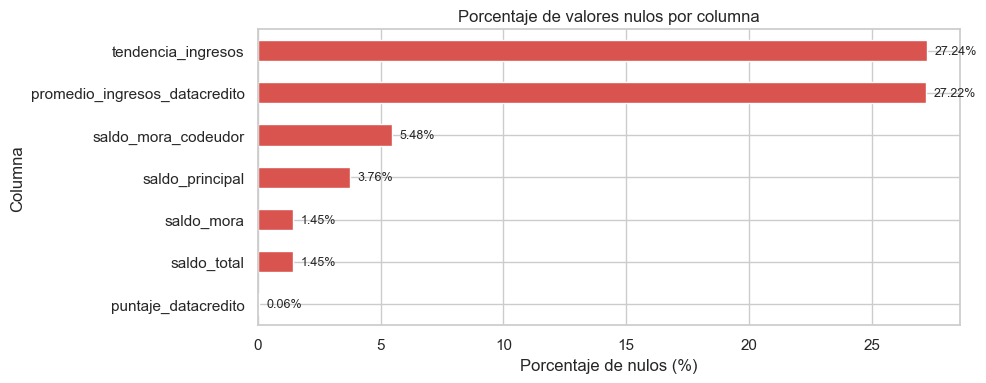

In [11]:
# Visualización: porcentaje de nulos por columna (solo las que tienen)
fig, ax = plt.subplots(figsize=(10, 4))
nulos_resumen['pct_nulos'].plot(kind='barh', ax=ax, color='#D9534F')
ax.set_xlabel('Porcentaje de nulos (%)')
ax.set_ylabel('Columna')
ax.set_title('Porcentaje de valores nulos por columna')
ax.invert_yaxis()  # La columna con más nulos arriba
for i, v in enumerate(nulos_resumen['pct_nulos']):
    ax.text(v + 0.3, i, f'{v:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
# Duplicados (filas completamente idénticas)
n_duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {n_duplicados}')
if n_duplicados > 0:
    print('\nMuestra de duplicados:')
    print(df[df.duplicated(keep=False)].head())

Filas duplicadas: 0


### 1.3 Estadísticas descriptivas

Resumen estadístico de variables numéricas y conteos para variables categóricas.

In [14]:
# Estadísticas para variables numéricas
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
tipo_credito,10763.00,5.41,2.34,4.00,4.00,4.00,9.00,68.00
capital_prestado,10763.00,2434315.00,1909642.76,360000.00,1224831.00,1921920.00,3084840.00,41444152.80
plazo_meses,10763.00,10.58,6.63,2.00,6.00,10.00,12.00,90.00
edad_cliente,10763.00,43.95,15.06,19.00,33.00,42.00,53.00,123.00
salario_cliente,10763.00,17216431.46,355476717.60,0.00,2000000.00,3000000.00,4875808.00,22000000000.00
total_otros_prestamos,10763.00,6238869.65,118418316.94,0.00,500000.00,1000000.00,2000000.00,6787675263.00
cuota_pactada,10763.00,243617.41,210493.69,23944.00,121041.50,182863.00,287833.50,3816752.00
puntaje,10763.00,91.17,16.47,-38.01,95.23,95.23,95.23,95.23
puntaje_datacredito,10757.00,780.79,104.88,-7.00,757.00,791.00,825.00,999.00
cant_creditosvigentes,10763.00,5.73,3.98,0.00,3.00,5.00,8.00,62.00


In [16]:
# Estadísticas para variables NO numéricas (object/string + datetime)
df.describe(include=['object', 'datetime']).T

,count,unique,top,freq,mean,min,25%,50%,75%,max
fecha_prestamo,10763,NaN,NaN,NaN,2025-04-16 23:06:02.111121664,2024-11-26 09:17:04,2025-01-20 17:33:07.500000,2025-03-27 16:23:12,2025-06-16 13:27:58,2026-04-26 18:43:52
tipo_laboral,10763,2,Empleado,6754,NaN,NaN,NaN,NaN,NaN,NaN
tendencia_ingresos,7831,46,Creciente,5294,NaN,NaN,NaN,NaN,NaN,NaN


### 1.4 Clasificación de variables

Para tratar cada variable según su naturaleza, se construye una función helper que las clasifica en categorías. La heurística pura no es suficiente: hay variables enteras con pocos valores únicos que son **cantidades** (plazo_meses, cant_creditosvigentes) y otras que son **códigos categóricos** (tipo_credito). Por ello, el helper combina heurística automática con una **lista explícita** de variables que son categóricas codificadas.

In [17]:
# Lista explícita de variables que son categóricas codificadas en formato numérico.
# Estas variables tienen pocos valores únicos pero esos valores son códigos, no cantidades.
CATEGORICAS_CODIFICADAS = [
    'tipo_credito',         # Códigos discretos [4, 6, 7, 9, 10, 68] - claramente IDs
    'saldo_mora_codeudor',  # Solo 4 valores únicos [0, 30, 470, 2145], parece categorizado
]

# Lista explícita de columnas especiales
COL_TARGET = 'Pago_atiempo'
COL_FECHA = 'fecha_prestamo'

def clasificar_variables(df, umbral_discreta=20):
    """
    Clasifica las columnas del DataFrame en categorías para guiar el análisis.
    
    Categorías:
    - target: la variable objetivo del modelo.
    - fecha: la columna temporal.
    - categorica_texto: dtype 'object'/'string'.
    - categorica_codificada: numéricas que son códigos (definidas explícitamente).
    - numerica_discreta: numéricas con <= umbral valores únicos (cantidades enteras).
    - numerica_continua: numéricas con > umbral valores únicos.
    
    Returns
    -------
    dict
        Diccionario con las listas de columnas por cada categoría.
    """
    clasif = {
        'target': [],
        'fecha': [],
        'categorica_texto': [],
        'categorica_codificada': [],
        'numerica_discreta': [],
        'numerica_continua': []
    }
    
    for col in df.columns:
        if col == COL_TARGET:
            clasif['target'].append(col)
        elif col == COL_FECHA:
            clasif['fecha'].append(col)
        elif col in CATEGORICAS_CODIFICADAS:
            clasif['categorica_codificada'].append(col)
        elif df[col].dtype == 'object' or pd.api.types.is_string_dtype(df[col]):
            clasif['categorica_texto'].append(col)
        elif df[col].nunique(dropna=True) <= umbral_discreta:
            clasif['numerica_discreta'].append(col)
        else:
            clasif['numerica_continua'].append(col)
    
    return clasif

# Aplicar la clasificación
clasificacion = clasificar_variables(df)

# Mostrar la clasificación de forma legible
for tipo, columnas in clasificacion.items():
    print(f'{tipo} ({len(columnas)}):')
    for c in columnas:
        print(f'  - {c}')
    print()

target (1):
  - Pago_atiempo

fecha (1):
  - fecha_prestamo

categorica_texto (2):
  - tipo_laboral
  - tendencia_ingresos

categorica_codificada (2):
  - tipo_credito
  - saldo_mora_codeudor

numerica_discreta (2):
  - plazo_meses
  - creditos_sectorCooperativo

numerica_continua (15):
  - capital_prestado
  - edad_cliente
  - salario_cliente
  - total_otros_prestamos
  - cuota_pactada
  - puntaje
  - puntaje_datacredito
  - cant_creditosvigentes
  - huella_consulta
  - saldo_mora
  - saldo_total
  - saldo_principal
  - creditos_sectorFinanciero
  - creditos_sectorReal
  - promedio_ingresos_datacredito



### 1.5 Análisis del target: `Pago_atiempo`

La variable objetivo es binaria: 1 si el cliente paga a tiempo, 0 si no.

Su distribución es crítica para el modelado, ya que define la dificultad del problema.

In [18]:
# Distribución del target en frecuencias absolutas y relativas
target_abs = df[COL_TARGET].value_counts(dropna=False)
target_rel = df[COL_TARGET].value_counts(normalize=True, dropna=False) * 100

resumen_target = pd.DataFrame({
    'frecuencia': target_abs,
    'porcentaje': target_rel.round(2)
})
print('Distribución de la variable objetivo:')
print(resumen_target)

# Cálculo del ratio de desbalance
if 0 in target_abs.index and 1 in target_abs.index:
    ratio_desbalance = target_abs[1] / target_abs[0]
    print(f'\nRatio clase 1 / clase 0: {ratio_desbalance:.2f}')
    print(f'Por cada cliente que NO paga a tiempo, hay {ratio_desbalance:.1f} que SÍ pagan.')

Distribución de la variable objetivo:
              frecuencia  porcentaje
Pago_atiempo                        
1                  10252       95.25
0                    511        4.75

Ratio clase 1 / clase 0: 20.06
Por cada cliente que NO paga a tiempo, hay 20.1 que SÍ pagan.


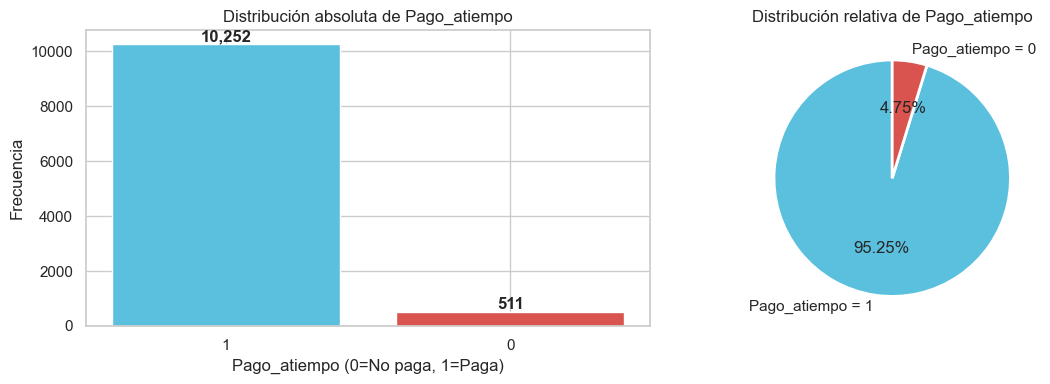

In [20]:
# Visualización del balance del target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Subplot 1: barras de frecuencia absoluta
colores = [COLORES_TARGET[v] for v in target_abs.index]
axes[0].bar(target_abs.index.astype(str), target_abs.values, color=colores)
axes[0].set_title('Distribución absoluta de Pago_atiempo')
axes[0].set_xlabel('Pago_atiempo (0=No paga, 1=Paga)')
axes[0].set_ylabel('Frecuencia')
for i, v in enumerate(target_abs.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Subplot 2: pastel con porcentajes
axes[1].pie(
    target_abs.values,
    labels=[f'Pago_atiempo = {v}' for v in target_abs.index],
    autopct='%1.2f%%',
    colors=colores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Distribución relativa de Pago_atiempo')

plt.tight_layout()
plt.show()

### 1.6 Observaciones del dataset crudo

Tras la exploración inicial, se identifican los siguientes puntos de atención que orientarán el resto del análisis y la futura ingeniería de características:

**Sobre los nulos:**

- `tendencia_ingresos` y `promedio_ingresos_datacredito` presentan ~27% de nulos cada una. Su conteo casi idéntico sugiere que ambos campos provienen de la misma fuente externa (probablemente DataCrédito) y faltan conjuntamente cuando esa fuente no devolvió información para el cliente.
- `saldo_mora_codeudor` tiene 5.48% de nulos, posiblemente vinculados a créditos sin codeudor.
- `saldo_principal`, `saldo_mora` y `saldo_total` presentan nulos menores (<4%) que requerirán imputación.

**Sobre las variables categóricas codificadas:**

- `tipo_credito` tiene 6 valores únicos `[4, 6, 7, 9, 10, 68]` que claramente son códigos identificadores, no cantidades. Se trata como variable categórica.
- `saldo_mora_codeudor` tiene únicamente 4 valores únicos `[0.0, 30.0, 470.0, 2145.0]`. Aunque su nombre sugiere un monto continuo, su distribución tan discreta sugiere que viene pre-categorizada. Se trata como categórica codificada.

**Sobre la calidad de `tendencia_ingresos`:**

- Esta variable mezcla categorías de texto ('Creciente', 'Decreciente', 'Estable') con valores numéricos en formato texto ('0', '8315', '1000000', etc.). Las tres categorías de texto suman ~99% de los valores no nulos; el resto son anomalías que deberán limpiarse en la fase de feature engineering.

**Sobre `tipo_laboral`:**

- Variable categórica de texto binaria con valores `'Empleado'` y `'Independiente'`. No presenta nulos.

**Sobre el desbalance del target:**

- `Pago_atiempo` está severamente desbalanceado (~95% pagan, ~5% no pagan). Esto tiene implicaciones críticas para el modelado:
    - La métrica `accuracy` será engañosa (un modelo que prediga siempre 'paga' tendrá ~95% de acierto sin aprender nada útil).
    - Se deberán usar métricas más informativas como ROC-AUC, F1-score y Precision-Recall, tal como exige el Proyecto Integrador.
    - El desbalance se manejará en el entrenamiento mediante `class_weight='balanced'`, `scale_pos_weight` (XGBoost) o técnicas de resampling.
    - La **clase de interés desde el negocio** es la minoritaria (clase 0, los que NO pagan a tiempo), ya que representan el riesgo crediticio que se busca anticipar.
